In [1]:
import sqlite3
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

DB = '../data/humans_clean.sqlite3'

conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

polities = [
    ('Mughal Empire (1497–1858)',
     "ic.polity_name LIKE '%Mughal%'", 1497, 1858),
    ('Song Dynasty (961–1278)',
     "ic.polity_name LIKE '%Song%' AND ic.polity_name NOT LIKE '%Songhai%' AND ic.polity_name NOT LIKE '%Liu Song%'",
     961, 1278),
    ('Mamluk Sultanate (1241–1518)',
     "ic.polity_name LIKE '%Mamluk Sultanate%'", 1241, 1518),
    ('Umayyad Caliphate (656–756)',
     "ic.polity_name LIKE '%Umayyad%'", 656, 756),
]

In [2]:
polity_data = []

for title, where, yr_start, yr_end in polities:
    cur = conn.execute(f'''
        SELECT i.occupations_en, ic.impact_date
        FROM individuals_cliopatria ic
        JOIN individuals i ON ic.wikidata_id = i.wikidata_id
        WHERE {where}
          AND i.occupations_en IS NOT NULL
          AND ic.impact_date IS NOT NULL
          AND ic.impact_date >= {yr_start}
          AND ic.impact_date <= {yr_end}
    ''')

    # Group occupation counts by century
    occ_by_century = defaultdict(Counter)
    individuals_by_century = defaultdict(set)
    row_id = 0
    for occs_str, year in cur:
        century = (year // 100) * 100  # e.g. 1523 -> 1500
        row_id += 1
        individuals_by_century[century].add(row_id)
        for occ in occs_str.split('; '):
            occ = occ.strip()
            if occ:
                occ_by_century[century][occ] += 1

    # Filter centuries: only keep full centuries within the polity range
    centuries = sorted(c for c in occ_by_century
                       if c >= (yr_start // 100) * 100
                       and c + 100 <= yr_end + 1)
    # If polity is short (< 200 years), keep all centuries with data
    if not centuries:
        centuries = sorted(occ_by_century.keys())

    polity_data.append((title, centuries, occ_by_century, individuals_by_century))
    print(f"{title}: centuries = {centuries}")

conn.close()

Mughal Empire (1497–1858): centuries = [1500, 1600, 1700]


Song Dynasty (961–1278): centuries = [900, 1000, 1100]


Mamluk Sultanate (1241–1518): centuries = [1200, 1300, 1400]


Umayyad Caliphate (656–756): centuries = [600]


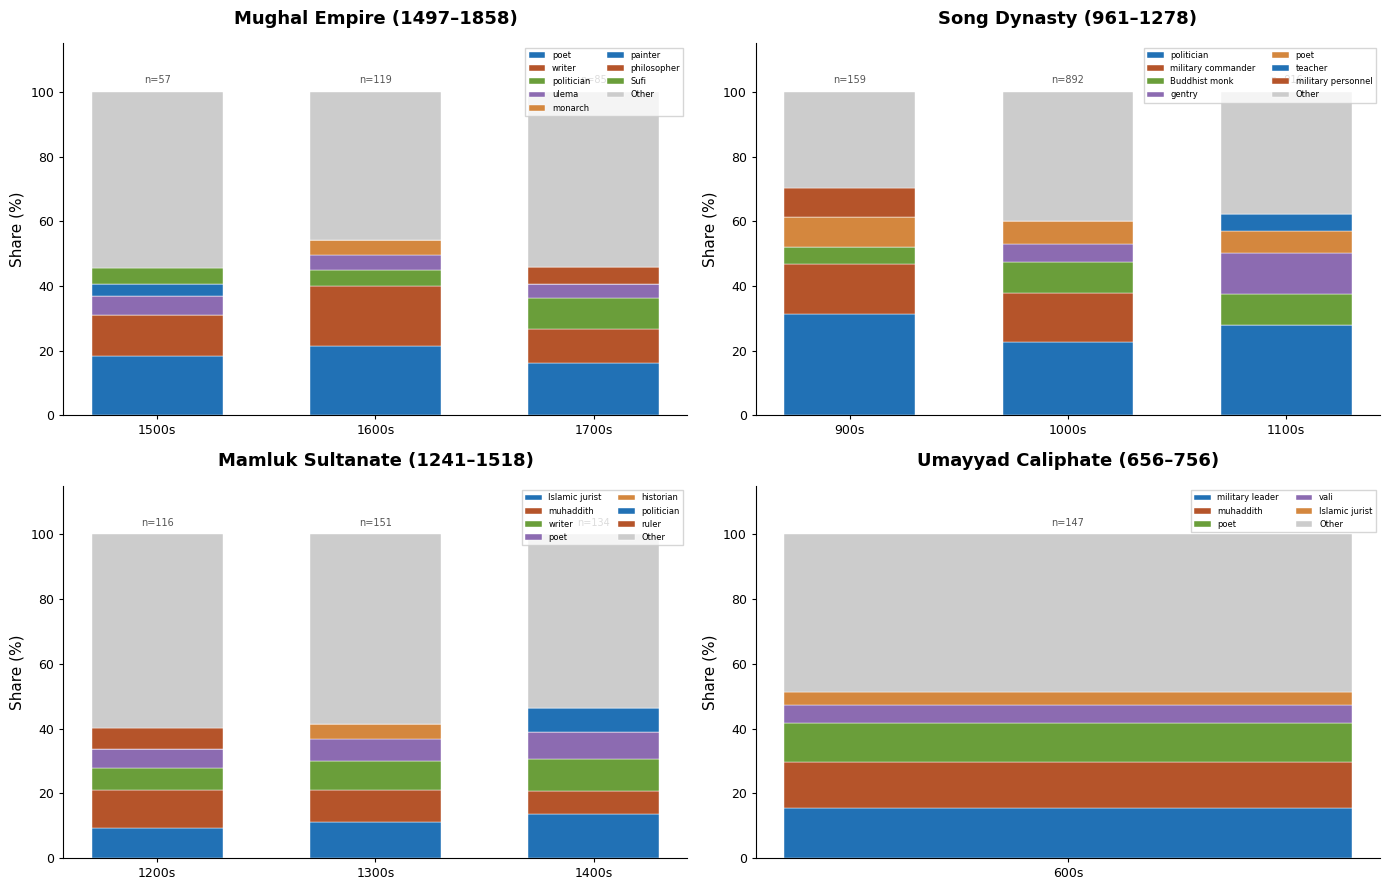

In [3]:
palette = ['#2171b5', '#b5542a', '#6a9e3a', '#8c6bb1', '#d4873e']
other_color = '#cccccc'

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for idx, (title, centuries, occ_by_century, individuals_by_century) in enumerate(polity_data):
    ax = axes[idx]

    # For each century, find top 5 occupations and compute shares
    century_labels = []
    top5_per_century = []
    shares_per_century = []  # list of dicts {occ: share}
    n_individuals = []

    for c in centuries:
        counter = occ_by_century[c]
        total = sum(counter.values())
        if total == 0:
            continue
        top5 = [occ for occ, _ in counter.most_common(5)]
        top5_per_century.append(top5)
        shares = {}
        for occ in top5:
            shares[occ] = counter[occ] / total * 100
        shares['Other'] = (1 - sum(counter[o] for o in top5) / total) * 100
        shares_per_century.append(shares)
        label = f"{c}s"
        century_labels.append(label)
        n_individuals.append(len(individuals_by_century[c]))

    # Collect all unique top-5 occupations across centuries (ordered by overall frequency)
    overall_counter = Counter()
    for c in centuries:
        overall_counter += occ_by_century[c]
    # Get all occupations that appeared in any century's top 5
    all_top_occs = []
    for t5 in top5_per_century:
        for occ in t5:
            if occ not in all_top_occs:
                all_top_occs.append(occ)
    # Sort by overall frequency
    all_top_occs.sort(key=lambda o: -overall_counter[o])

    # Build stacked bar data: for each century, each occupation gets its share or 0
    x = np.arange(len(century_labels))
    bar_width = 0.6
    bottoms = np.zeros(len(century_labels))

    for i, occ in enumerate(all_top_occs):
        vals = []
        for shares in shares_per_century:
            vals.append(shares.get(occ, 0))
        color = palette[i % len(palette)]
        ax.bar(x, vals, bar_width, bottom=bottoms, label=occ,
               color=color, edgecolor='white', linewidth=0.3)
        bottoms += np.array(vals)

    # "Other" on top
    other_vals = [s.get('Other', 0) for s in shares_per_century]
    ax.bar(x, other_vals, bar_width, bottom=bottoms, label='Other',
           color=other_color, edgecolor='white', linewidth=0.3)

    # Annotate individual count on top of each bar
    for j, n in enumerate(n_individuals):
        ax.text(j, 102, f'n={n}', ha='center', va='bottom', fontsize=7,
                color='#555555')

    ax.set_xticks(x)
    ax.set_xticklabels(century_labels, fontsize=9)
    ax.set_ylim(0, 115)
    ax.set_ylabel('Share (%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', color='black',
                 loc='center', pad=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=3, labelsize=9)

    # Legend below the title, compact
    ax.legend(fontsize=6, loc='upper right', frameon=True, fancybox=False,
              edgecolor='#cccccc', ncol=2)

plt.tight_layout()
plt.show()